In [1]:
# Imports and configuration
import os
import json
import torch
import torchvision
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
import torchvision.transforms.functional as F
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
import numpy as np

# Device configuration
if not torch.cuda.is_available():
    raise RuntimeError("CUDA GPU is required but was not found.")

DEVICE = torch.device("cuda")
print(f"Using device: {DEVICE}")

# Paths
DATA_ROOT = "."
TEST_JSON = os.path.join(DATA_ROOT, "test", "_annotations.coco.json")
MODEL_PATH = os.path.join("models", "defect_detector_stage2_litho_finetuned.pth")

# Load test annotations
with open(TEST_JSON, "r") as f:
    test_coco = json.load(f)

test_images = test_coco["images"]
test_annotations = test_coco["annotations"]

# Create image_id to annotations mapping
from collections import defaultdict
image_id_to_anns = defaultdict(list)
for ann in test_annotations:
    image_id_to_anns[ann["image_id"]].append(ann)

print(f"Loaded {len(test_images)} test images")
print(f"Model path: {MODEL_PATH}")


Using device: cuda
Loaded 150 test images
Model path: models\defect_detector_stage2_litho_finetuned.pth


In [2]:
# Load the fine-tuned model
def create_defect_detector(one_class=True):
    if one_class:
        num_classes = 2  # background + defect
    else:
        num_classes = 8  # background + 7 defect categories

    model = torchvision.models.detection.fasterrcnn_resnet50_fpn(weights="DEFAULT")
    in_features = model.roi_heads.box_predictor.cls_score.in_features
    model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)
    return model

model = create_defect_detector(one_class=True)
model.load_state_dict(torch.load(MODEL_PATH, map_location=DEVICE))
model.to(DEVICE)
model.eval()

print("Model loaded successfully!")


Model loaded successfully!


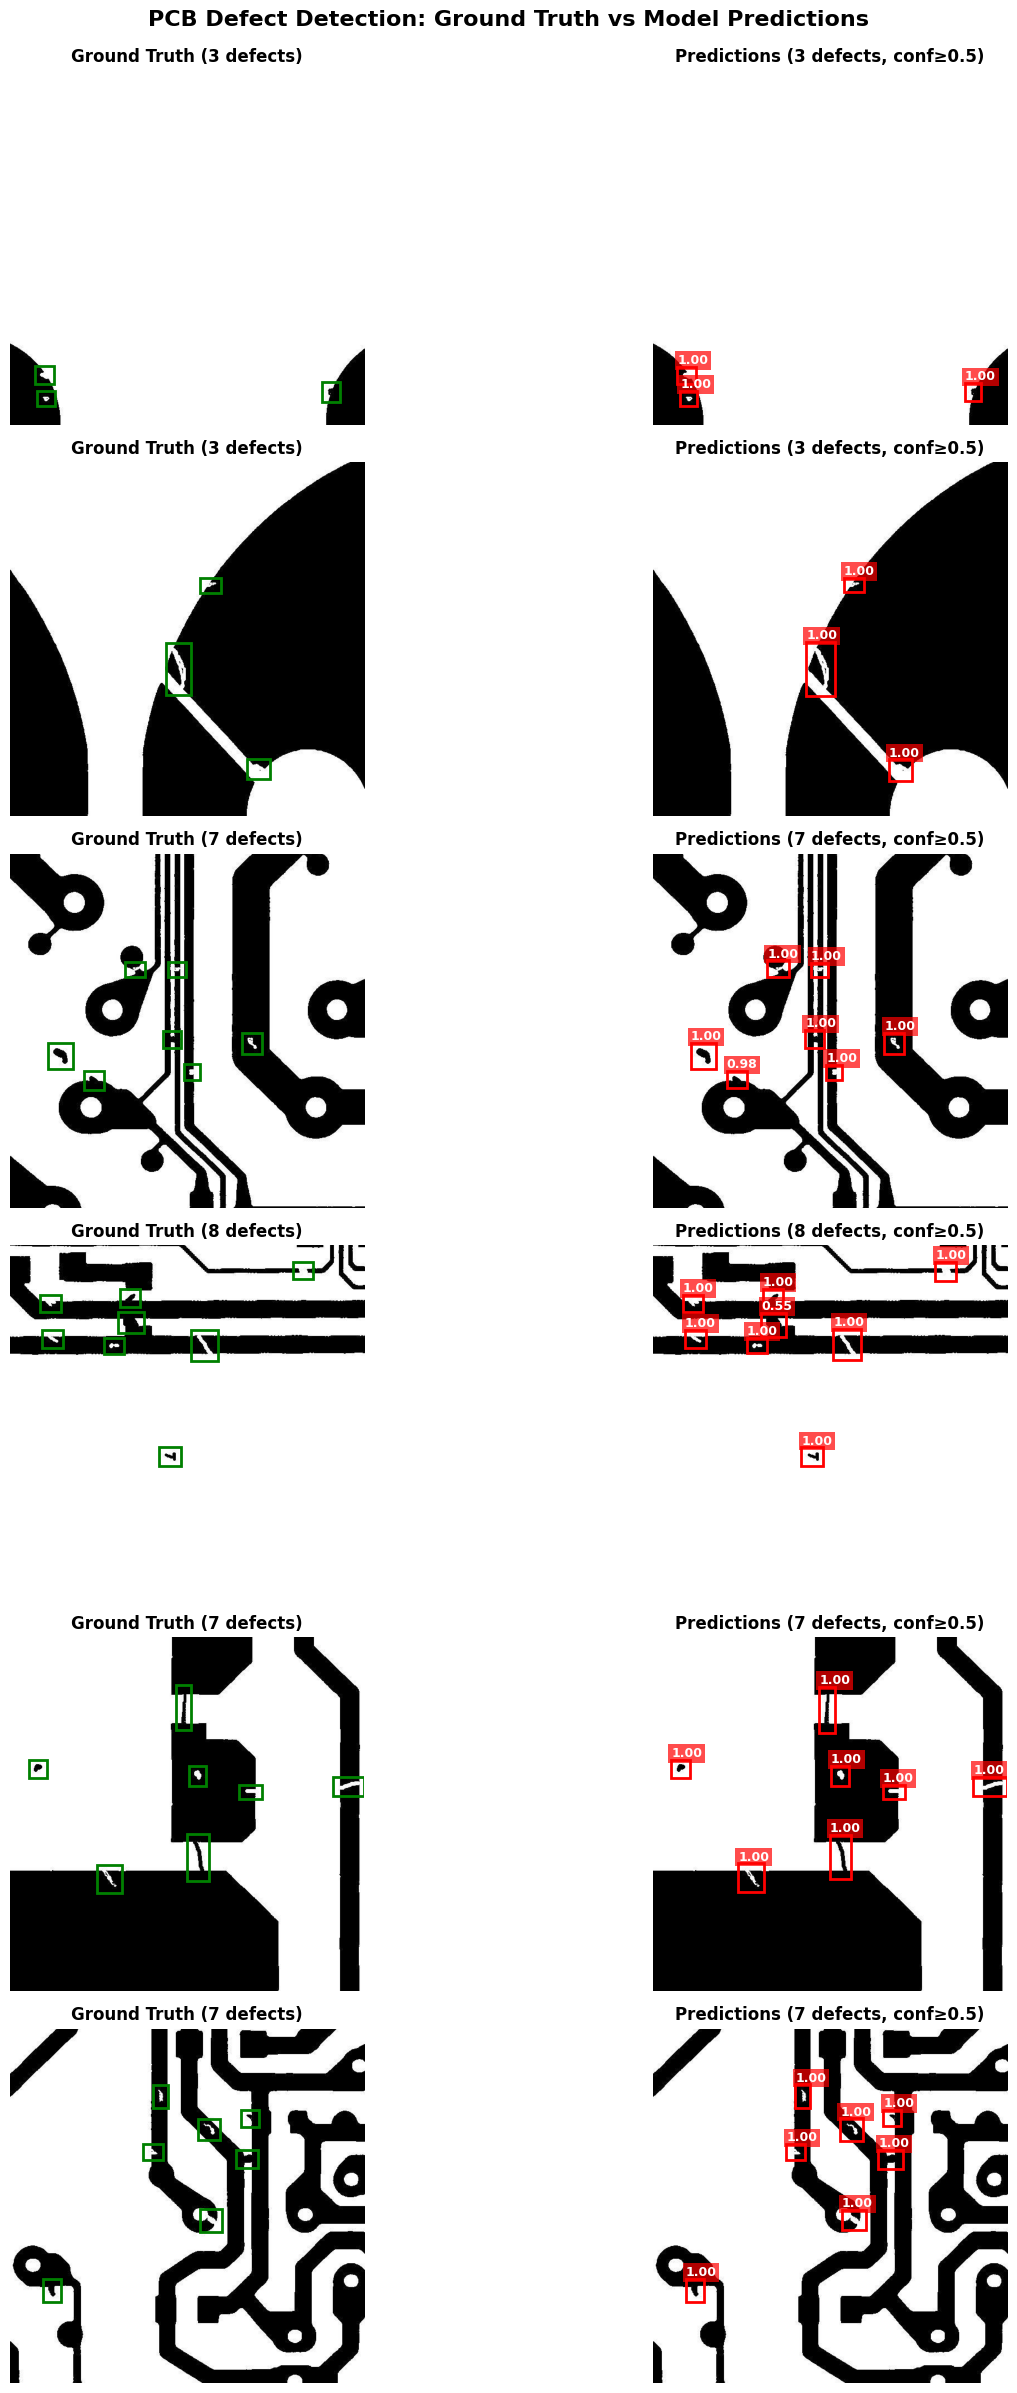


Visualized 6 test images with confidence threshold = 0.5


In [3]:
# Run inference on test images and visualize results
num_samples = 6
confidence_threshold = 0.5

# Select random test images
np.random.seed(42)
sample_indices = np.random.choice(len(test_images), num_samples, replace=False)

fig, axes = plt.subplots(num_samples, 2, figsize=(16, 4 * num_samples))

for idx, img_idx in enumerate(sample_indices):
    img_info = test_images[img_idx]
    image_id = img_info["id"]
    file_name = img_info["file_name"]
    
    # Load image
    img_path = os.path.join("test", file_name)
    img = Image.open(img_path).convert("RGB")
    img_np = np.array(img)
    
    # Get ground truth annotations
    gt_anns = image_id_to_anns[image_id]
    
    # Left: Original image with ground truth
    ax_left = axes[idx, 0]
    ax_left.imshow(img_np)
    ax_left.set_title(f"Ground Truth ({len(gt_anns)} defects)", fontsize=12, fontweight="bold")
    ax_left.axis("off")
    
    for ann in gt_anns:
        x, y, w, h = ann["bbox"]
        rect = patches.Rectangle((x, y), w, h, linewidth=2, edgecolor="green", facecolor="none")
        ax_left.add_patch(rect)
    
    # Right: Model predictions
    ax_right = axes[idx, 1]
    ax_right.imshow(img_np)
    
    # Run inference
    img_tensor = F.to_tensor(img).unsqueeze(0).to(DEVICE)
    
    with torch.no_grad():
        predictions = model(img_tensor)[0]
    
    # Filter predictions by confidence
    scores = predictions["scores"].cpu().numpy()
    boxes = predictions["boxes"].cpu().numpy()
    labels = predictions["labels"].cpu().numpy()
    
    mask = scores >= confidence_threshold
    filtered_boxes = boxes[mask]
    filtered_scores = scores[mask]
    
    ax_right.set_title(f"Predictions ({len(filtered_boxes)} defects, conf≥{confidence_threshold})", 
                       fontsize=12, fontweight="bold")
    ax_right.axis("off")
    
    for box, score in zip(filtered_boxes, filtered_scores):
        x1, y1, x2, y2 = box
        w = x2 - x1
        h = y2 - y1
        rect = patches.Rectangle((x1, y1), w, h, linewidth=2, edgecolor="red", facecolor="none")
        ax_right.add_patch(rect)
        
        # Add confidence score label
        ax_right.text(x1, y1 - 5, f"{score:.2f}", 
                     bbox=dict(facecolor="red", alpha=0.7, edgecolor="none", pad=2),
                     fontsize=9, color="white", fontweight="bold")

plt.suptitle("PCB Defect Detection: Ground Truth vs Model Predictions", 
             fontsize=16, fontweight="bold", y=0.995)
plt.tight_layout()
plt.show()

print(f"\nVisualized {num_samples} test images with confidence threshold = {confidence_threshold}")
